We take an image, convert it into a format the model understands using a processor, pass it through a pretrained transformer-based segmentation model, and then convert the model’s pixel-wise predictions into a mask where each pixel is assigned a class.

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

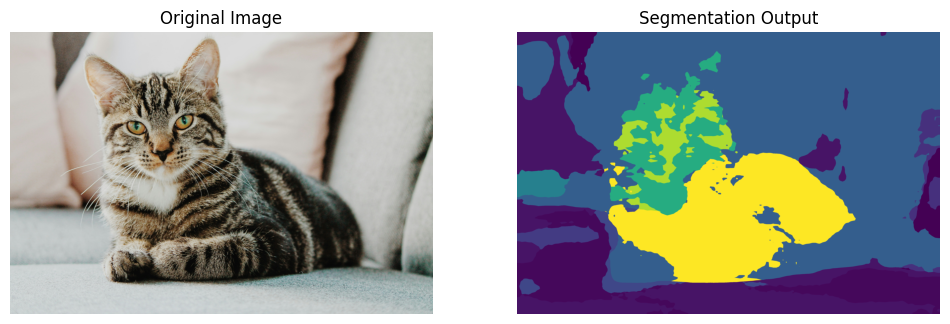

In [1]:
# Took 5 minutes

from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch
import numpy as np
from PIL import Image
import requests
import matplotlib.pyplot as plt


# Load image
url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131"
image = Image.open(requests.get(url, stream=True).raw)
MODEL = "nvidia/segformer-b0-finetuned-ade-512-512"

# Prepares the image for the model: Resize, Normalize pixel values, Convert to tensor
processor = SegformerImageProcessor.from_pretrained(MODEL)


model = SegformerForSemanticSegmentation.from_pretrained(MODEL)

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

# Resize to original image size
upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

pred_mask = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

plt.figure(figsize=(12,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Segmentation Output
plt.subplot(1,2,2)
plt.imshow(pred_mask)
plt.title("Segmentation Output")
plt.axis("off")

plt.show()
